In [1]:
import os

file_path = r"C:\Users\HP PC\Downloads\archive (6)\Dataset_BUSI_with_GT"

print(os.listdir(file_path))

['benign', 'malignant', 'normal']


### Convert Masks To YOLO Labels

This is the MOST important stage.

We will:

* read image
* read mask
* find lesion contour
* extract bounding box
* save YOLO annotation

In [2]:
import os
import cv2
import shutil
import random

# =========================
# PATHS
# =========================

dataset_path = r"C:\Users\HP PC\Downloads\archive (6)\Dataset_BUSI_with_GT"

output_path = r"C:\Users\HP PC\Downloads\BUSI_YOLO"

# Create YOLO folders
folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(output_path, folder), exist_ok=True)

# =========================
# CLASS MAPPING
# =========================

classes = {
    "benign": 0,
    "malignant": 1
}

# =========================
# COLLECT IMAGES
# =========================

all_data = []

for cls in ["benign", "malignant"]:

    class_path = os.path.join(dataset_path, cls)

    for file in os.listdir(class_path):

        # Skip masks
        if "_mask" in file:
            continue

        if file.endswith(".png"):

            image_path = os.path.join(class_path, file)

            mask_name = file.replace(".png", "_mask.png")
            mask_path = os.path.join(class_path, mask_name)

            # Ensure mask exists
            if os.path.exists(mask_path):

                all_data.append({
                    "image": image_path,
                    "mask": mask_path,
                    "class": classes[cls],
                    "filename": file
                })

# =========================
# TRAIN/VAL SPLIT
# =========================

random.shuffle(all_data)

split_idx = int(0.8 * len(all_data))

train_data = all_data[:split_idx]
val_data = all_data[split_idx:]

# =========================
# FUNCTION TO PROCESS DATA
# =========================

def process_dataset(data, split):

    for item in data:

        image = cv2.imread(item["image"])
        mask = cv2.imread(item["mask"], 0)

        h, w = image.shape[:2]

        # Find contours
        contours, _ = cv2.findContours(
            mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        label_lines = []

        for contour in contours:

            x, y, bw, bh = cv2.boundingRect(contour)

            # Convert to YOLO format
            x_center = (x + bw / 2) / w
            y_center = (y + bh / 2) / h
            width = bw / w
            height = bh / h

            line = f"{item['class']} {x_center} {y_center} {width} {height}"

            label_lines.append(line)

        # Save image
        save_image_path = os.path.join(
            output_path,
            f"images/{split}/{item['filename']}"
        )

        shutil.copy(item["image"], save_image_path)

        # Save label
        label_filename = item["filename"].replace(".png", ".txt")

        save_label_path = os.path.join(
            output_path,
            f"labels/{split}/{label_filename}"
        )

        with open(save_label_path, "w") as f:
            f.write("\n".join(label_lines))

# =========================
# RUN PROCESSING
# =========================

process_dataset(train_data, "train")
process_dataset(val_data, "val")

print("BUSI YOLO dataset prepared successfully!")

BUSI YOLO dataset prepared successfully!


In [3]:
import yaml

with open(r"C:\Users\HP PC\Downloads\BUSI_YOLO\data.yaml", "r") as f:
    data = yaml.safe_load(f)

print(data)

{'path': 'C:/Users/HP PC/Downloads/BUSI_YOLO', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'benign', 1: 'malignant'}}


### your data.yaml is now perfectly configured. 

YOLO can now successfully:

* locate your dataset
* load training images
* load validation images
* read bounding box labels
* understand your classes

You are officially ready for:

BUSI lesion detection training using YOLO.

### Train YOLO

In [4]:
from ultralytics import YOLO

# Load pretrained YOLOv8 nano model
model = YOLO("yolov8n.pt")

# Start training
model.train(
    data=r"C:\Users\HP PC\Downloads\BUSI_YOLO\data.yaml",
    epochs=50,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.60  Python-3.9.23 torch-2.3.1 CPU (Intel Core i5-8250U 1.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\HP PC\Downloads\BUSI_YOLO\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000027F1AA292E0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

### visually inspect the detector.

### WHY PREDICTION IS IMPORTANT

Now you can see:

* how YOLO localizes lesions
* whether boxes are tight
* whether small lesions are missed
* whether false positives occur

This is critical in:

* medical imaging
* radiology AI
* CAD systems

### Load Your Best Model

In [6]:
from ultralytics import YOLO

model = YOLO(
    r"C:\Users\HP PC\runs\detect\train-4\weights\best.pt"
)

### Run Prediction On Validation Images

In [7]:
results = model.predict(
    source=r"C:\Users\HP PC\Downloads\BUSI_YOLO\images\val",
    conf=0.25,
    show=True
)


image 1/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (102).png: 640x640 1 benign, 164.4ms
image 2/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (104).png: 480x640 1 benign, 140.4ms
image 3/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (106).png: 576x640 2 benigns, 149.9ms
image 4/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (109).png: 544x640 2 benigns, 168.3ms
image 5/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (111).png: 640x448 1 benign, 131.6ms
image 6/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (112).png: 608x640 1 benign, 158.4ms
image 7/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (114).png: 512x640 1 benign, 137.4ms
image 8/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (116).png: 512x640 1 benign, 119.7ms
image 9/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (120).png: 576x640 1 benign, 123.5ms
image 10/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (125).png: 51

### SHOW FEWER IMAGES

If you want only a few predictions displayed interactively:

In [8]:
results = model.predict(
    source=r"C:\Users\HP PC\Downloads\BUSI_YOLO\images\val",
    conf=0.25,
    show=True,
    save=True,
    max_det=2
)


image 1/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (102).png: 640x640 1 benign, 129.7ms
image 2/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (104).png: 480x640 1 benign, 105.3ms
image 3/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (106).png: 576x640 2 benigns, 121.0ms
image 4/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (109).png: 544x640 2 benigns, 118.9ms
image 5/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (111).png: 640x448 1 benign, 94.3ms
image 6/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (112).png: 608x640 1 benign, 127.1ms
image 7/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (114).png: 512x640 1 benign, 111.7ms
image 8/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (116).png: 512x640 1 benign, 114.4ms
image 9/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (120).png: 576x640 1 benign, 119.1ms
image 10/319 C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (125).png: 512

### display and save only a few validation images with bounding boxes

In [10]:
from ultralytics import YOLO

# Load trained model
model = YOLO(
    r"C:\Users\HP PC\runs\detect\train-4\weights\best.pt"
)

# Predict on selected images
results = model.predict(
    source=[
        r"C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\benign (405).png",
        r"C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\malignant (142).png",
        r"C:\Users\HP PC\Downloads\BUSI_YOLO\images\val\malignant (198).png"
    ],
    conf=0.25,
    show=True,
    save=True
)


0: 640x640 1 benign, 102.8ms
1: 640x640 1 malignant, 102.8ms
2: 640x640 (no detections), 102.8ms
Speed: 23.1ms preprocess, 102.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\HP PC\runs\detect\predict-3


### BETTER WAY TO DISPLAY INSIDE NOTEBOOK

If you want images displayed directly inside notebook cells,

In [13]:
import os

folder = r"C:\Users\HP PC\runs\detect\predict-3"

print(os.listdir(folder))

['image0.jpg', 'image1.jpg', 'image2.jpg']


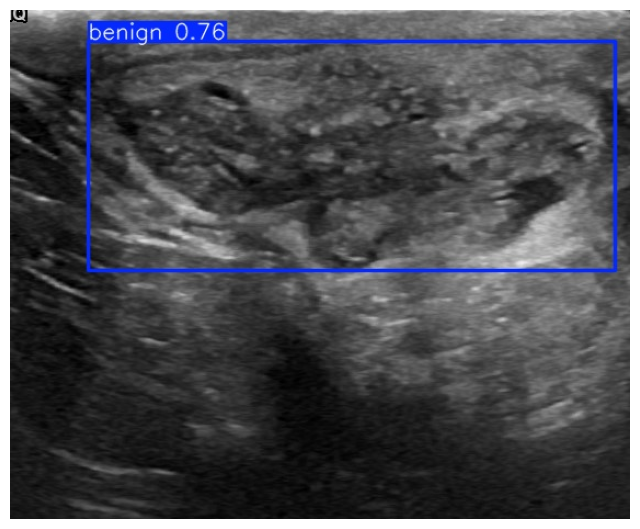

In [16]:
%matplotlib inline

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(
    r"C:\Users\HP PC\runs\detect\predict-3\image0.jpg"
)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

### Let us view few of the Validation predicted images  

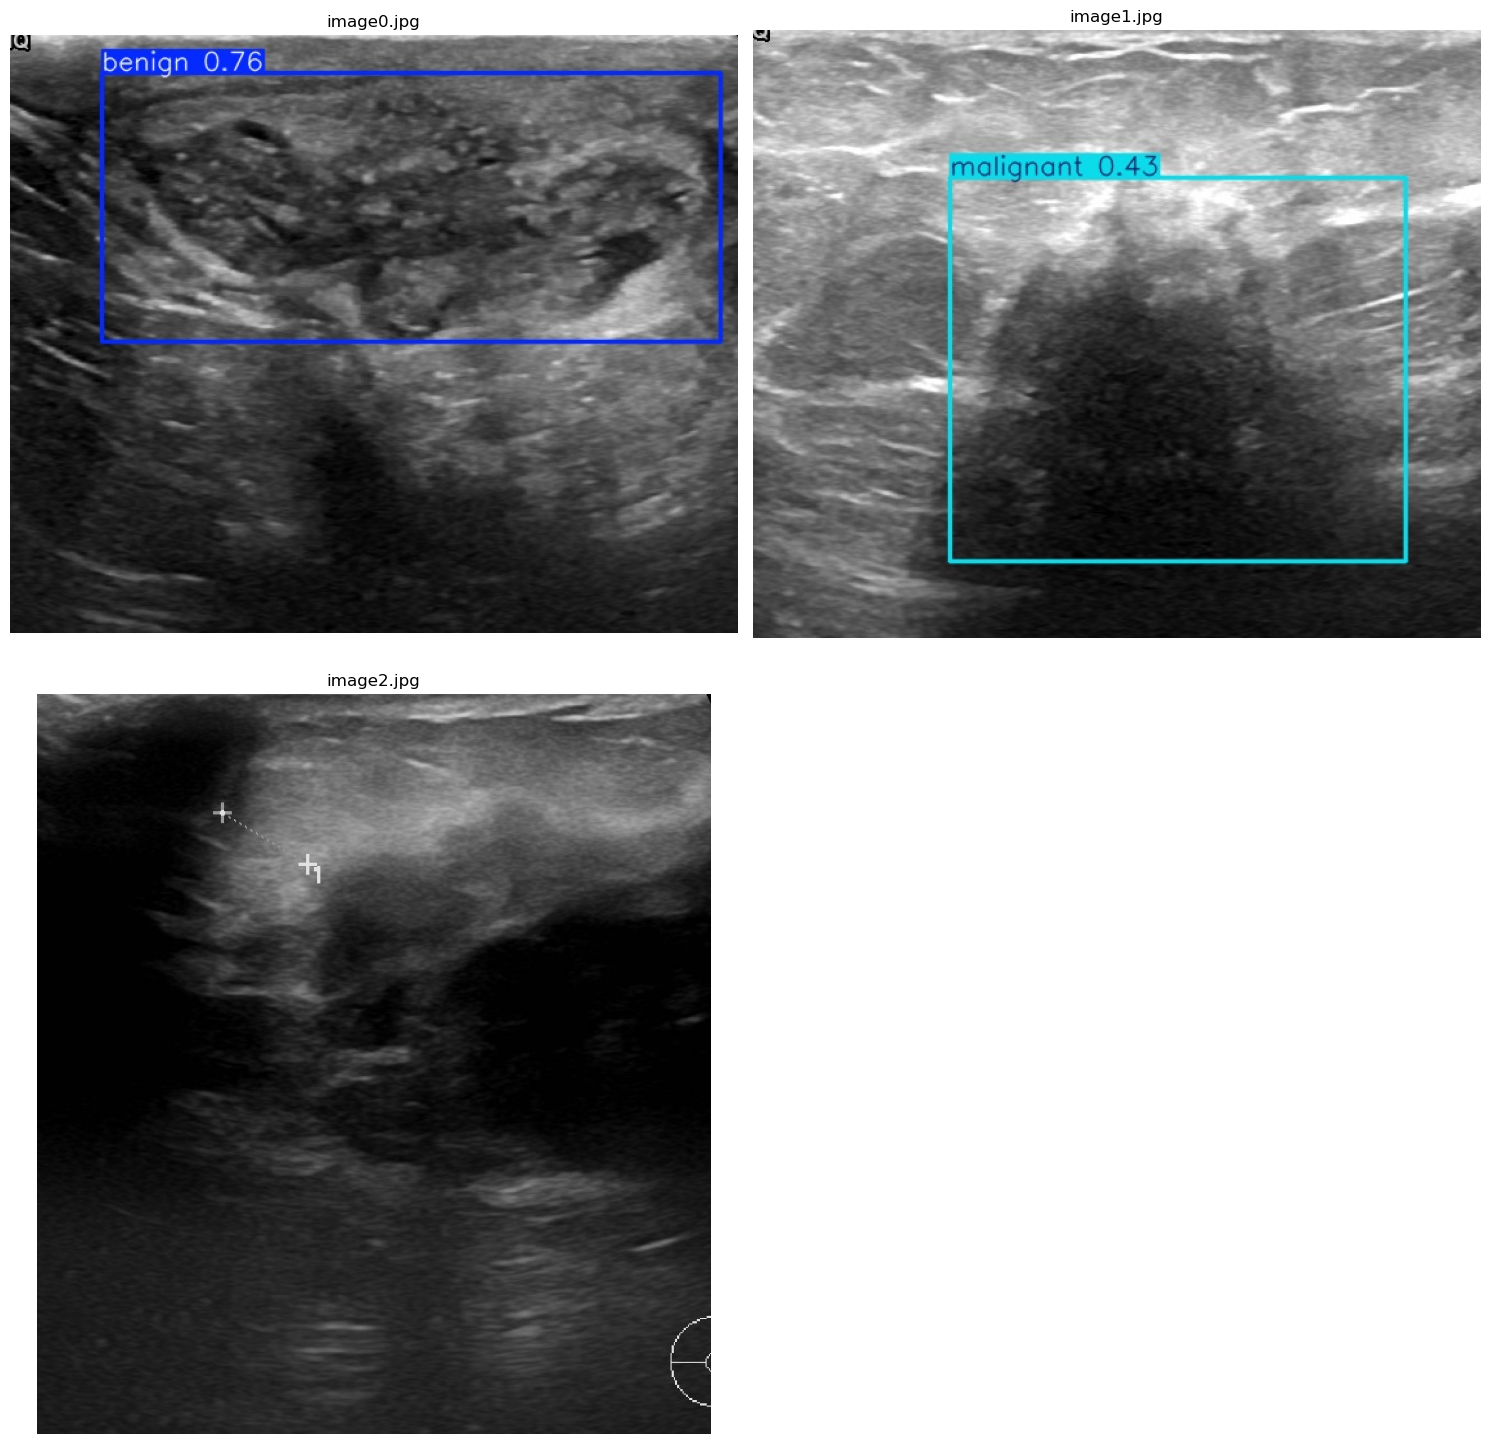

In [18]:
%matplotlib inline

import os
from PIL import Image
import matplotlib.pyplot as plt

# Prediction folder
folder = r"C:\Users\HP PC\runs\detect\predict-3"

# Get actual image filenames
files = os.listdir(folder)

# Take first 4 images
files = files[:4]

plt.figure(figsize=(15,15))

for i, file in enumerate(files):

    path = os.path.join(folder, file)

    img = Image.open(path)

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()